# Meu primeiro Notebook Jupyter
---

Lendo o livro `Data Science do Zero` me senti na nescessidade de testar o exemplo do conjunto de dados iris para os **K-Nearest Neibors**, encontrei dificuldades apenas no uso dos objetos do pacote `scratch` porém obtive ele no repositório oficial do livro (achava que era uma biblioteca como matplotlib por exemplo).

## Importações e dowload dos dados

In [1]:
import requests, csv
from typing import Dict, List, NamedTuple
from collections import defaultdict
from matplotlib import pyplot as plt
from scratch.linear_algebra import Vector

In [2]:
data = requests.get(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
)

with open("iris.dat", 'w') as f:
    f.write(data.text)

# Tratamento  dos dados 
---
Seguindo o tutorial do livro, após baixar os dados, começei o tratamento, gerei conjunto de dados das espécies e tranferi cada cado para um rótulo específico.

In [3]:
class LabeledPoint(NamedTuple):
    point: Vector
    label: str

def parse_iris_row(row: List[str]) -> LabeledPoint:
    """
    Separa os tamanho e largura das petalas e cepalas, e por fim classe
    """

    mensuramentos = [float(valor) for valor in row[:-1]]

    rotulos = row[-1].split("-")[-1]

    return LabeledPoint(mensuramentos, rotulos)

with open("iris.dat") as f:
    reader = csv.reader(f)
    # O 'if row' descarta listas vazias []
    iris_data = [parse_iris_row(row) for row in reader if row]

pontos_especie: Dict[str, List[Vector]] = defaultdict(list)

for iris in iris_data:
    pontos_especie[iris.label].append(iris.point)

# Plotagem
---
Por fim, apenas segui o código de como gerar os gráficos para desmontrar onde cada medida de cada flor cosutma ficar, gerando assim uma representação mais simples de como as espécies se diferenciam.

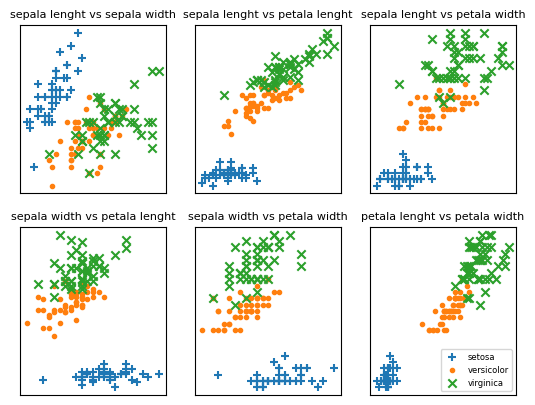

In [6]:
metricas = ['sepala lenght', 'sepala width', 'petala lenght', 'petala width']
pares = [(i,j) for i in range(4) for j in range(4) if i < j]
marcas = ["+",".","x"]

fig, ax = plt.subplots(2,3)

for row in range(2):
    for col in range(3):
        i, j = pares[3 * row + col]
        ax[row][col].set_title(f"{metricas[i]} vs {metricas[j]}", fontsize=8)
        ax[row][col].set_xticks([])
        ax[row][col].set_yticks([])

        for mark, (species, pontos) in zip(marcas, pontos_especie.items()):
            xs = [ponto[i] for ponto in pontos]
            ys = [ponto[j] for ponto in pontos]
            ax[row][col].scatter(xs,ys, marker=mark, label=species)

ax[-1][-1].legend(loc="lower right", prop={'size': 6})
plt.show()
        

# Considerações finais 
